# Advanced Time Series Models

Volatility models on **NIFTY 50** daily returns, then Prophet and XGBoost on the **bakery** daily sales, scored against the SARIMAX baseline from [model_selection.ipynb](model_selection.ipynb) with MAE, RMSE, MAPE, sMAPE and CRPS.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from arch import arch_model
from prophet import Prophet
import xgboost as xgb

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- NIFTY 50 daily returns (for ARCH / GARCH)
nifty = pd.read_csv("../data/nifty50_daily.csv", parse_dates=["ds"]).set_index("ds")
ret = 100 * np.log(nifty["close"]).diff().dropna()

# --- bakery daily sales (for Prophet / XGBoost)
bakery = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
y = (bakery[bakery["unique_id"] == "TRADITIONAL BAGUETTE"]
     .sort_values("ds").set_index("ds")["y"].asfreq("D"))
is_closed = (y == 0).astype(float)

H = 28
train, test = y[:-H], y[-H:]

print(f"NIFTY returns : {len(ret)} obs   mean {ret.mean():.4f}   std {ret.std():.3f}   kurtosis {ret.kurtosis():.2f}")
print(f"bakery        : train {len(train)}   test {len(test)}   zeros in test {int((test == 0).sum())}")

d:\User\vscode\timeseries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


NIFTY returns : 2464 obs   mean 0.0421   std 1.028   kurtosis 22.24
bakery        : train 609   test 28   zeros in test 1


## 1. ARCH

Every model so far assumed **constant error variance**. Financial returns violate that visibly: calm stretches and turbulent stretches cluster together. Large moves follow large moves, regardless of sign.

ARCH models the *variance* as a function of past squared shocks. With $\varepsilon_t = \sigma_t z_t$, $z_t \sim \text{iid}(0,1)$:

$$\sigma_t^2 = \omega + \sum_{i=1}^{q}\alpha_i \varepsilon_{t-i}^2, \qquad \omega > 0,\ \alpha_i \ge 0$$

The variance today is a weighted sum of recent squared surprises — so a big move mechanically raises tomorrow's expected variance.

**Detecting ARCH effects.** Returns themselves are near-unpredictable, but their *squares* are not. Apply Ljung-Box to $\varepsilon_t^2$: rejection means the variance is autocorrelated.

**Limitation.** Capturing slowly-decaying volatility memory needs a large $q$ — many parameters, all constrained non-negative. GARCH fixes exactly this.

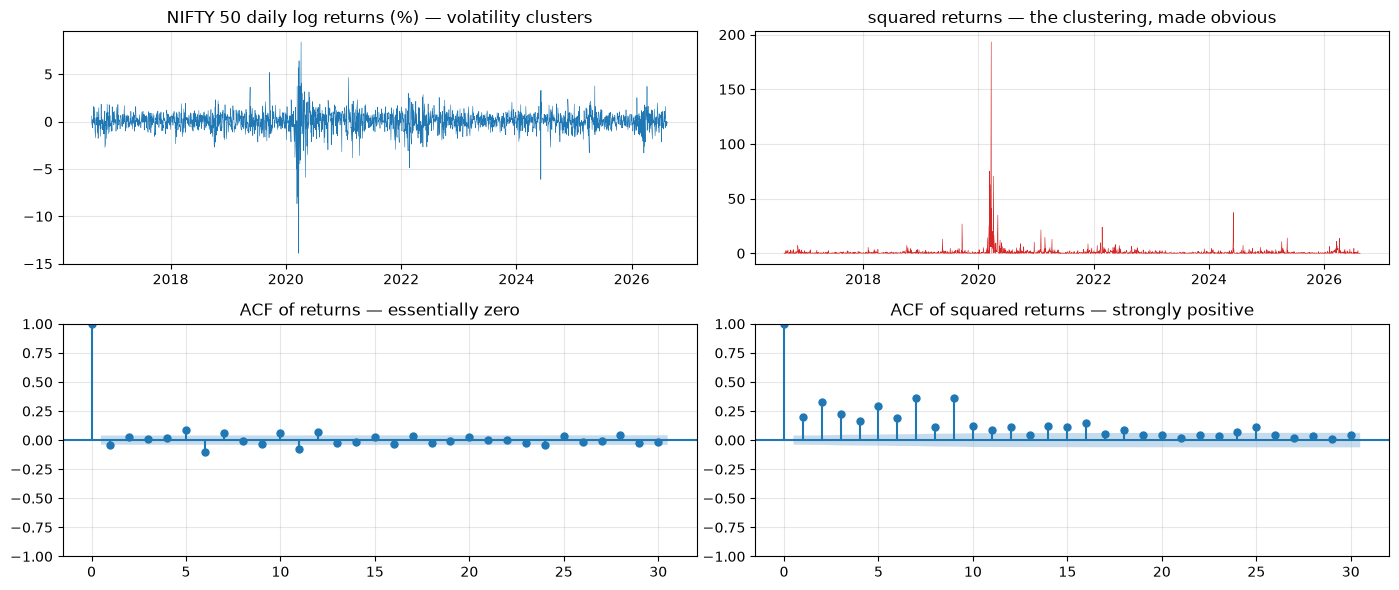

Ljung-Box(10)  returns          p = 1.76e-11
Ljung-Box(10)  squared returns  p = 0   <- ARCH effects present


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

axes[0, 0].plot(ret.index, ret.values, lw=0.4)
axes[0, 0].set_title("NIFTY 50 daily log returns (%) — volatility clusters")
axes[0, 1].plot(ret.index, ret.values ** 2, lw=0.4, color="tab:red")
axes[0, 1].set_title("squared returns — the clustering, made obvious")
for a in axes[0]:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plot_acf(ret, lags=30, ax=axes[1, 0]);        axes[1, 0].set_title("ACF of returns — essentially zero")
plot_acf(ret ** 2, lags=30, ax=axes[1, 1]);   axes[1, 1].set_title("ACF of squared returns — strongly positive")
plt.tight_layout(); plt.show()

print(f"Ljung-Box(10)  returns          p = {acorr_ljungbox(ret, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.3g}")
print(f"Ljung-Box(10)  squared returns  p = {acorr_ljungbox(ret**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.3g}"
      "   <- ARCH effects present")

In [3]:
arch1 = arch_model(ret, mean="Constant", vol="ARCH", p=1).fit(disp="off")
arch5 = arch_model(ret, mean="Constant", vol="ARCH", p=5).fit(disp="off")

for name, m in [("ARCH(1)", arch1), ("ARCH(5)", arch5)]:
    print(f"{name:10s} logLik {m.loglikelihood:9.1f}   AIC {m.aic:9.1f}   BIC {m.bic:9.1f}   params {len(m.params)}")

ARCH(1)    logLik   -3301.7   AIC    6609.5   BIC    6626.9   params 3
ARCH(5)    logLik   -3132.8   AIC    6279.6   BIC    6320.3   params 7


The returns' own ACF is flat while the squared returns' ACF is large and positive out to 30 lags — the level is unpredictable but the **variance is not**. Ljung-Box on squared returns gives p ≈ 0.

Going from ARCH(1) to ARCH(5) improves AIC from 6609.5 to 6279.6, which says one lag is nowhere near enough. That is the argument for GARCH.

## 2. GARCH

GARCH adds lagged *variance* to the recursion, so volatility memory decays geometrically instead of being truncated at $q$:

$$\sigma_t^2 = \omega + \sum_{i=1}^{p}\alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{q}\beta_j \sigma_{t-j}^2$$

**GARCH(1,1)** — three parameters, and enough for most financial series:

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$$

| Quantity | Meaning |
|---|---|
| $\alpha$ | reaction — how sharply volatility jumps after a shock |
| $\beta$ | persistence — how long the elevated level lasts |
| $\alpha + \beta$ | total persistence; must be $< 1$ for stationarity |
| $\omega/(1-\alpha-\beta)$ | unconditional (long-run) variance |
| $\log(0.5)/\log(\alpha+\beta)$ | half-life of a volatility shock |

$\alpha + \beta$ close to 1 means shocks decay slowly. Forecasts of $\sigma^2_{T+h}$ converge to the unconditional variance from wherever volatility is today — the practical payoff, since option pricing and risk limits need exactly that path.

**Fat tails.** A Gaussian $z_t$ rarely suffices; returns stay leptokurtic even after conditioning on $\sigma_t$. Student-$t$ innovations usually fit far better.

In [4]:
garch   = arch_model(ret, mean="Constant", vol="GARCH", p=1, q=1).fit(disp="off")
garch_t = arch_model(ret, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")

for name, m in [("ARCH(1)", arch1), ("ARCH(5)", arch5),
                ("GARCH(1,1)", garch), ("GARCH(1,1)-t", garch_t)]:
    print(f"{name:14s} logLik {m.loglikelihood:9.1f}   AIC {m.aic:9.1f}   BIC {m.bic:9.1f}   params {len(m.params)}")

w, a, b = garch.params["omega"], garch.params["alpha[1]"], garch.params["beta[1]"]
print(f"\nGARCH(1,1):  ω={w:.4f}  α={a:.4f}  β={b:.4f}")
print(f"  persistence α+β        = {a+b:.4f}")
print(f"  half-life of a shock   = {np.log(0.5)/np.log(a+b):.1f} days")
print(f"  unconditional vol      = {np.sqrt(w/(1-a-b)*252):.2f}% annualised")
print(f"  realised sample vol    = {ret.std()*np.sqrt(252):.2f}% annualised")

ARCH(1)        logLik   -3301.7   AIC    6609.5   BIC    6626.9   params 3
ARCH(5)        logLik   -3132.8   AIC    6279.6   BIC    6320.3   params 7
GARCH(1,1)     logLik   -3090.5   AIC    6189.1   BIC    6212.3   params 4
GARCH(1,1)-t   logLik   -3036.0   AIC    6082.0   BIC    6111.0   params 5

GARCH(1,1):  ω=0.0252  α=0.1102  β=0.8635
  persistence α+β        = 0.9736
  half-life of a shock   = 26.0 days
  unconditional vol      = 15.51% annualised
  realised sample vol    = 16.32% annualised


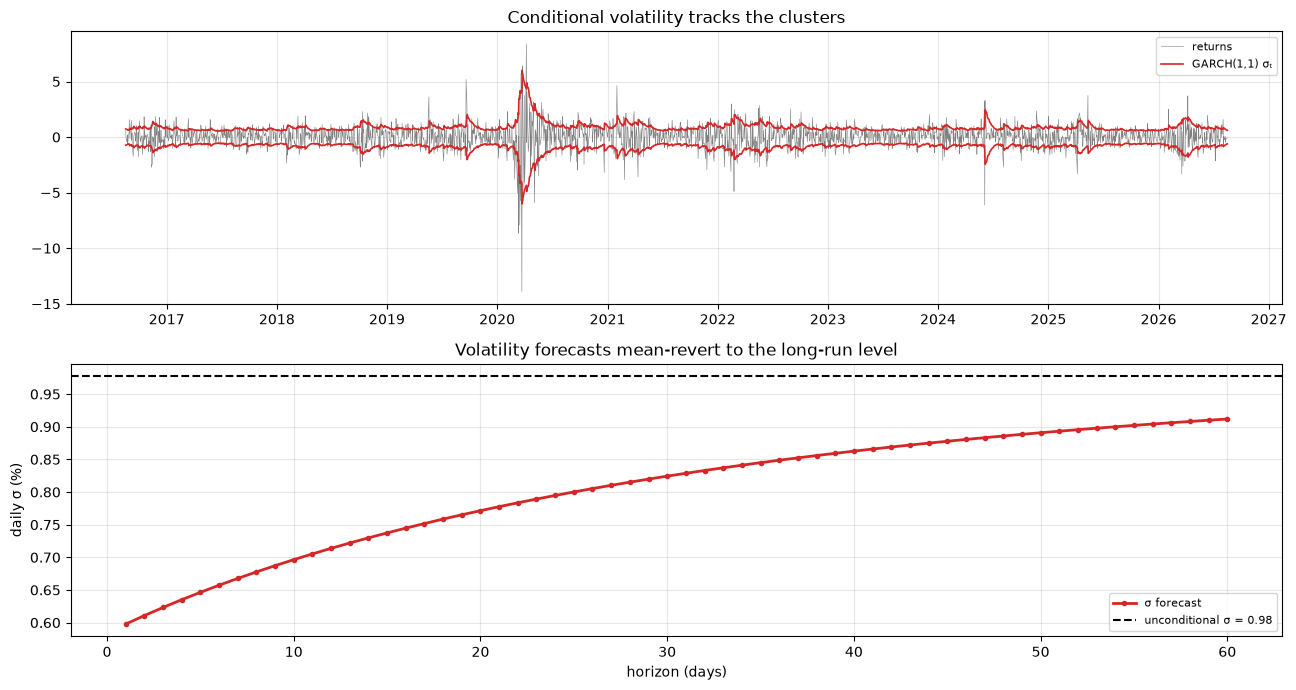

standardised residuals: kurtosis 1.69  (raw returns 22.24)
Ljung-Box(10) on squared standardised residuals p = 0.321


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(ret.index, ret.values, lw=0.4, color="grey", label="returns")
axes[0].plot(ret.index, garch.conditional_volatility, lw=1.2, color="tab:red", label="GARCH(1,1) σₜ")
axes[0].plot(ret.index, -garch.conditional_volatility, lw=1.2, color="tab:red")
axes[0].set_title("Conditional volatility tracks the clusters")
axes[0].legend(fontsize=8)

f = garch.forecast(horizon=60, reindex=False)
sig = np.sqrt(f.variance.values[0])
uncond = np.sqrt(w / (1 - a - b))
axes[1].plot(range(1, 61), sig, lw=2, marker="o", ms=3, color="tab:red", label="σ forecast")
axes[1].axhline(uncond, color="black", ls="--", label=f"unconditional σ = {uncond:.2f}")
axes[1].set_xlabel("horizon (days)"); axes[1].set_ylabel("daily σ (%)")
axes[1].set_title("Volatility forecasts mean-revert to the long-run level")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

std_resid = garch.std_resid.dropna()
print(f"standardised residuals: kurtosis {std_resid.kurtosis():.2f}  (raw returns {ret.kurtosis():.2f})")
print(f"Ljung-Box(10) on squared standardised residuals p = "
      f"{acorr_ljungbox(std_resid**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.3f}")

**GARCH(1,1) beats ARCH(5) with four parameters instead of seven** — AIC 6189.1 vs 6279.6. That is the parsimony argument in one line, and the reason GARCH(1,1) is the default.

$\alpha + \beta = 0.974$: highly persistent, with a **26-day half-life** for a volatility shock. The implied unconditional volatility of **15.5% annualised** sits close to the realised 16.3%.

The GARCH fit also **removes the ARCH effects**: Ljung-Box on the squared standardised residuals gives p = 0.32, against p ≈ 0 for the raw squared returns. The variance clustering has been modelled away.

Switching to Student-$t$ innovations gains another 107 AIC points (6082.0 vs 6189.1). Conditioning on $\sigma_t$ removes most of the fat tails but not all — **excess kurtosis falls from 22.24 to 1.69** (`pandas` reports *excess* kurtosis, so 0 is Gaussian). Still leptokurtic, which is exactly why the $t$ distribution fits better.

## 3. Prophet

Prophet treats forecasting as **curve fitting**, not as a stochastic process. It is an additive decomposable model:

$$y_t = g(t) + s(t) + h(t) + \varepsilon_t$$

| Term | What it is |
|---|---|
| $g(t)$ | trend — piecewise linear (or logistic) with automatically detected **changepoints** |
| $s(t)$ | seasonality — Fourier series, one per period (weekly, yearly, …) |
| $h(t)$ | holidays/events — user-supplied irregular effects with optional windows |
| $\varepsilon_t$ | i.i.d. noise |

Because everything is a function of the **timestamp**, Prophet extrapolates to any horizon, tolerates missing rows and outliers, and needs no stationarity. The trade-off: no autoregression at all — it never uses $y_{t-1}$ — so it cannot exploit short-run momentum.

The bakery's Wednesday closures are exactly what $h(t)$ is for.

01:53:04 - cmdstanpy - INFO - Chain [1] start processing
01:53:04 - cmdstanpy - INFO - Chain [1] done processing


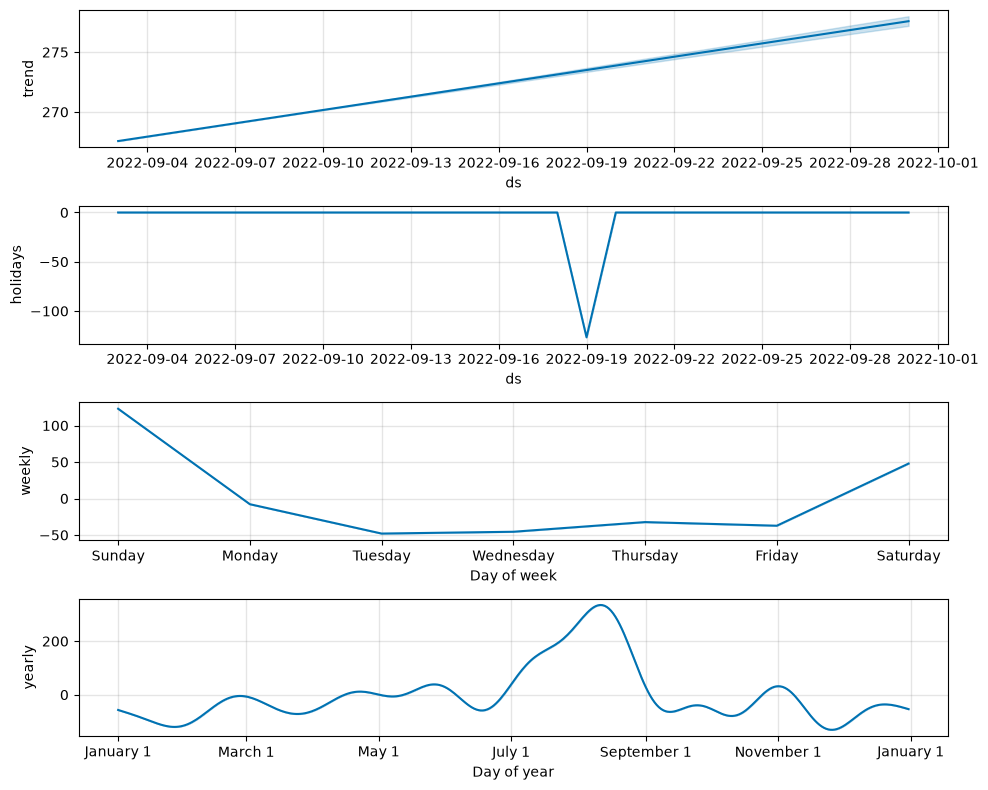

In [6]:
holidays = pd.DataFrame({"holiday": "closed",
                         "ds": y.index[is_closed == 1],
                         "lower_window": 0, "upper_window": 0})

def fit_prophet(tr, future_index, yearly=True, holis=holidays):
    m = Prophet(weekly_seasonality=True, yearly_seasonality=yearly, daily_seasonality=False,
                holidays=holis, interval_width=0.8, uncertainty_samples=1000)
    m.fit(pd.DataFrame({"ds": tr.index, "y": tr.values}))
    fut = pd.DataFrame({"ds": future_index})
    return m, m.predict(fut), m.predictive_samples(fut)["yhat"]

m_p, fc_p, samples_p = fit_prophet(train, test.index)

fig = m_p.plot_components(fc_p)
fig.set_size_inches(10, 8)
plt.tight_layout(); plt.show()

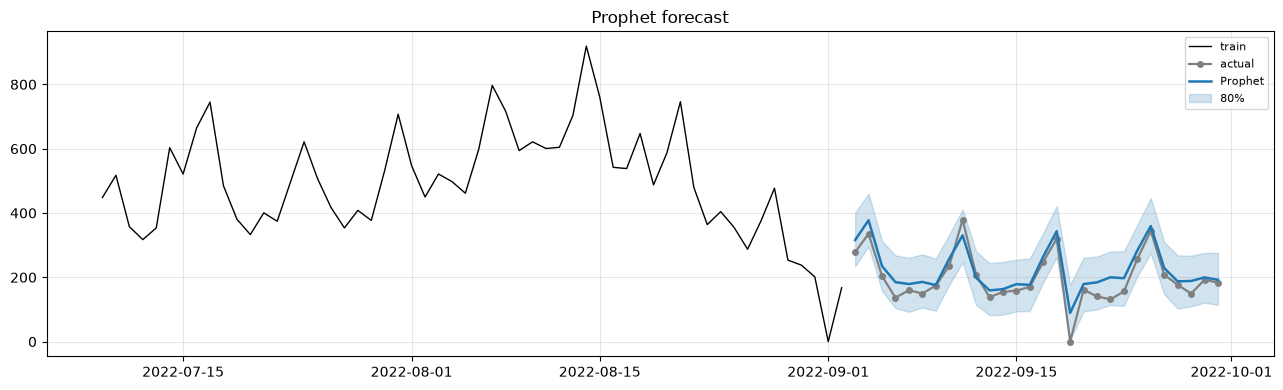

01:53:05 - cmdstanpy - INFO - Chain [1] start processing
01:53:05 - cmdstanpy - INFO - Chain [1] done processing
01:53:05 - cmdstanpy - INFO - Chain [1] start processing
01:53:05 - cmdstanpy - INFO - Chain [1] done processing


yearly_seasonality=True   MAE   27.86   RMSE   34.15
yearly_seasonality=False  MAE  316.28   RMSE  317.44


In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index[-56:], train.values[-56:], lw=1, color="black", label="train")
ax.plot(test.index, test.values, lw=1.6, color="grey", marker="o", ms=4, label="actual")
ax.plot(test.index, fc_p["yhat"], lw=1.8, color="tab:blue", label="Prophet")
ax.fill_between(test.index, fc_p["yhat_lower"], fc_p["yhat_upper"], alpha=0.2, color="tab:blue", label="80%")
ax.legend(fontsize=8); ax.set_title("Prophet forecast")
plt.tight_layout(); plt.show()

# does the yearly term earn its place on only 1.7 years of history?
for yearly in (True, False):
    _, fc_, _ = fit_prophet(train, test.index, yearly=yearly)
    e_ = test.values - fc_["yhat"].values
    print(f"yearly_seasonality={str(yearly):5s}  MAE {np.abs(e_).mean():7.2f}   RMSE {np.sqrt((e_**2).mean()):7.2f}")

**Prophet warns that yearly seasonality is under-identified below 730 days of history — we have 609 — but turning it off is catastrophic: MAE goes from 27.9 to 316.3.**

The reason is visible in the components plot. The training data ends just after the August peak, and the test window is September. Without a yearly term the piecewise-linear trend extrapolates the summer climb and overshoots by an order of magnitude; with it, Prophet knows September falls back. The warning is about *identifiability*, not about usefulness — here the annual cycle is the dominant signal, so a poorly-identified estimate of it beats none at all.

Worth taking as the general lesson: a library warning is a prompt to test the alternative, not an instruction to follow.

## 4. XGBoost with lag features

Gradient boosting has no notion of time. The series must be reshaped into a **supervised learning table**, one row per timestamp, using exactly the features from [feature_engineering.ipynb](feature_engineering.ipynb):

| Feature group | Examples |
|---|---|
| lags | `lag_7`, `lag_14`, `lag_21`, `lag_28` |
| rolling stats | `rmean_7`, `rstd_7`, `rmin_28`, `rmax_28` |
| calendar | `dow`, `month`, `doy`, cyclical `dow_sin`/`dow_cos` |
| exogenous | `is_closed` |

Two rules carry over unchanged: every lag must satisfy $k \ge h$, and rolling windows must be shifted by $h$ — otherwise the model trains on information it will not have.

**Strengths:** captures non-linearities and interactions automatically, ignores irrelevant features, handles exogenous variables natively, no stationarity requirement.

**The structural weakness: trees cannot extrapolate.** A tree predicts the average of training rows in a leaf, so it can never output a value outside the training range. On a trending series it will flatten at the last observed level. The standard fixes are to model the differenced series, or to detrend first and add the trend back.

**Prediction intervals** come from quantile regression — fit one model per quantile with the pinball loss.

feature matrix (603, 19)   train (575, 18)   test (28, 18)


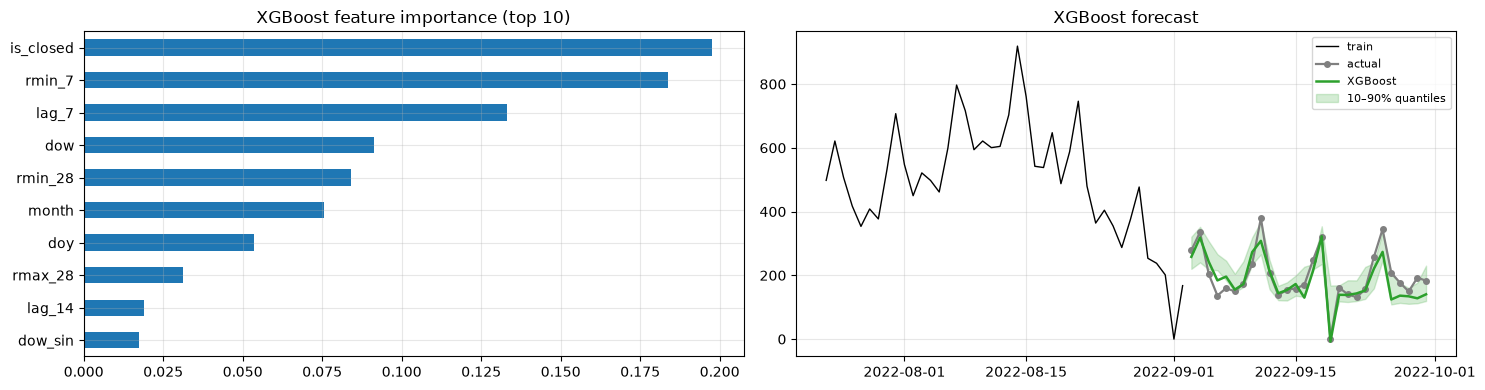

is_closed    0.198
rmin_7       0.184
lag_7        0.133
dow          0.091
rmin_28      0.084
month        0.075


In [8]:
def make_features(s, closed, lags=(7, 14, 21, 28), windows=(7, 28), h=7):
    '''Leakage-safe supervised table: every feature uses data at or before t - h.'''
    df = pd.DataFrame({"y": s})
    for L in lags:
        assert L >= h
        df[f"lag_{L}"] = s.shift(L)
    base = s.shift(h)
    for w in windows:
        df[f"rmean_{w}"] = base.rolling(w).mean()
        df[f"rstd_{w}"]  = base.rolling(w).std()
        df[f"rmin_{w}"]  = base.rolling(w).min()
        df[f"rmax_{w}"]  = base.rolling(w).max()
    ix = s.index
    df["dow"], df["month"], df["doy"] = ix.dayofweek, ix.month, ix.dayofyear
    df["dow_sin"] = np.sin(2 * np.pi * ix.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * ix.dayofweek / 7)
    df["is_closed"] = closed.values
    return df

F = make_features(y, is_closed).dropna()
F_tr = F[F.index <= train.index[-1]]
F_te = F[F.index > train.index[-1]]
X_tr, y_tr = F_tr.drop(columns="y"), F_tr["y"]
X_te, y_te = F_te.drop(columns="y"), F_te["y"]

print(f"feature matrix {F.shape}   train {X_tr.shape}   test {X_te.shape}")

xgb_reg = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=0, n_jobs=1)     # n_jobs=1 for reproducibility
xgb_reg.fit(X_tr, y_tr)
pred_x = xgb_reg.predict(X_te)

TAUS = np.arange(0.05, 1.0, 0.05)
Q = np.column_stack([
    xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=t, n_estimators=300,
                     max_depth=4, learning_rate=0.05,
                     random_state=0, n_jobs=1).fit(X_tr, y_tr).predict(X_te)
    for t in TAUS])                                     # 19 quantile models — takes ~10s

imp = pd.Series(xgb_reg.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
imp.head(10)[::-1].plot.barh(ax=axes[0])
axes[0].set_title("XGBoost feature importance (top 10)")

axes[1].plot(train.index[-42:], train.values[-42:], lw=1, color="black", label="train")
axes[1].plot(test.index, test.values, lw=1.6, color="grey", marker="o", ms=4, label="actual")
axes[1].plot(test.index, pred_x, lw=1.8, color="tab:green", label="XGBoost")
axes[1].fill_between(test.index, Q[:, 1], Q[:, -2], alpha=0.2, color="tab:green", label="10–90% quantiles")
axes[1].legend(fontsize=8); axes[1].set_title("XGBoost forecast")
plt.tight_layout(); plt.show()

print(imp.head(6).round(3).to_string())

`is_closed`, `rmin_7` and `lag_7` dominate — the model has independently found the closure calendar and the weekly cycle. Note it never sees `lag_1`: at a 7-day horizon that value does not exist yet.

## 5. LSTM — high-level intuition

A plain RNN processes a sequence step by step, carrying a hidden state $h_t$. Gradients propagated back through many steps shrink geometrically, so it **forgets** long-range dependencies — the vanishing-gradient problem.

An LSTM adds a **cell state** $C_t$ that flows through time with only linear operations, plus three gates that decide what to write to it:

$$\begin{aligned}
f_t &= \sigma(W_f[h_{t-1}, x_t] + b_f) && \text{forget — what to erase from } C_{t-1}\\
i_t &= \sigma(W_i[h_{t-1}, x_t] + b_i) && \text{input — what new information to store}\\
o_t &= \sigma(W_o[h_{t-1}, x_t] + b_o) && \text{output — what to expose as } h_t\\
C_t &= f_t \odot C_{t-1} + i_t \odot \tanh(W_C[h_{t-1}, x_t] + b_C)\\
h_t &= o_t \odot \tanh(C_t)
\end{aligned}$$

The point is the **additive** update to $C_t$. Because information is added rather than repeatedly multiplied by a weight matrix, gradients survive far longer, letting the network hold state over hundreds of steps.

**When it is worth it:** long or non-linear dependencies, many related series to learn jointly, rich exogenous inputs. **When it is not:** a few hundred observations, or a series whose structure is trend + seasonality — the classical models are faster, interpretable, and usually as accurate. LSTMs need scaling, windowing, a validation split, and careful regularisation, and they produce point forecasts unless explicitly built to output distributions.

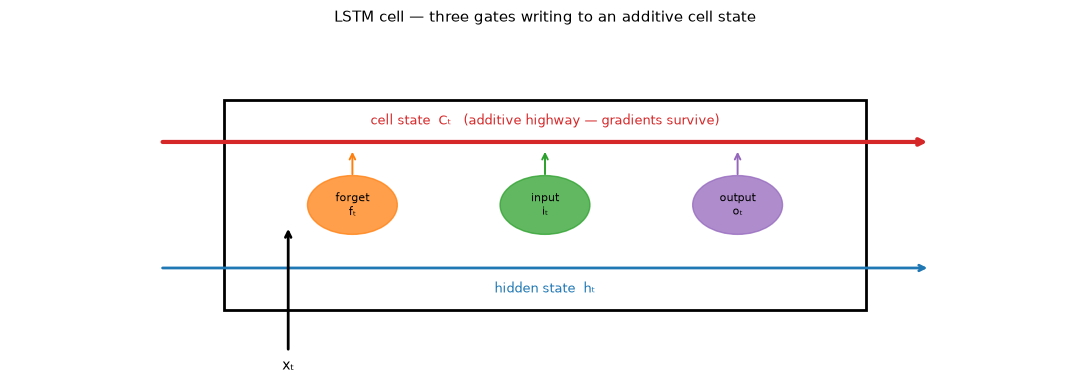

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")

ax.add_patch(plt.Rectangle((2, 1), 6, 3, fill=False, lw=2))
ax.annotate("", xy=(8.6, 3.4), xytext=(1.4, 3.4), arrowprops=dict(arrowstyle="->", lw=3, color="tab:red"))
ax.text(5, 3.65, "cell state  Cₜ   (additive highway — gradients survive)",
        ha="center", fontsize=9, color="tab:red")
ax.annotate("", xy=(8.6, 1.6), xytext=(1.4, 1.6), arrowprops=dict(arrowstyle="->", lw=2, color="tab:blue"))
ax.text(5, 1.25, "hidden state  hₜ", ha="center", fontsize=9, color="tab:blue")

for x_, lab, col in [(3.2, "forget\nfₜ", "tab:orange"), (5.0, "input\niₜ", "tab:green"), (6.8, "output\noₜ", "tab:purple")]:
    ax.add_patch(plt.Circle((x_, 2.5), 0.42, color=col, alpha=0.75))
    ax.text(x_, 2.5, lab, ha="center", va="center", fontsize=8)
    ax.annotate("", xy=(x_, 3.3), xytext=(x_, 2.9), arrowprops=dict(arrowstyle="->", lw=1.4, color=col))

ax.annotate("", xy=(2.6, 2.2), xytext=(2.6, 0.4), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(2.6, 0.15, "xₜ", ha="center", fontsize=10)
ax.set_title("LSTM cell — three gates writing to an additive cell state", fontsize=11)
plt.tight_layout(); plt.show()

## 6. Transformers for forecasting — high-level

A transformer drops recurrence entirely. Every timestep looks at every other timestep **in parallel** through self-attention:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Each position emits a query $Q$, and every position offers a key $K$ and value $V$. The dot product $QK^\top$ scores how relevant each other timestep is; the softmax turns those into weights; the output is the weighted sum of values. The path between any two timesteps is **length 1**, versus $O(n)$ for an RNN — which is why long-range dependencies are easier to learn.

Because there is no recurrence, order must be injected explicitly via **positional encoding**.

| Concern | Note |
|---|---|
| Cost | attention is $O(n^2)$ in sequence length; Informer, Autoformer and FEDformer exist to reduce it |
| Data | tens of thousands of observations, or many related series — not one short series |
| Patching | PatchTST groups timesteps into patches, cutting cost and improving accuracy |
| Covariates | Temporal Fusion Transformer handles static + known-future + observed inputs, with interpretable attention |

**The honest caveat.** *Are Transformers Effective for Time Series Forecasting?* (Zeng et al., 2022) showed a one-layer linear model beating several published transformers on standard benchmarks. Later work (PatchTST, TimesNet) recovered the lead, but the lesson stands: on a single series with a few hundred points, a transformer will lose to SARIMA. These architectures earn their keep on large panels of related series — demand across thousands of SKUs, load across many meters.

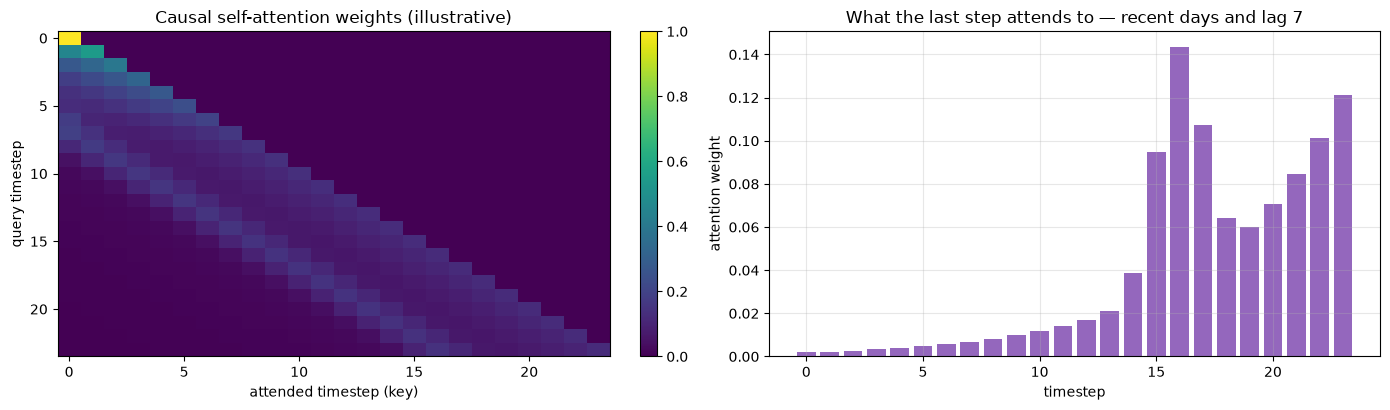

This figure is a hand-built illustration of the attention pattern, not a trained model.


In [10]:
n_steps = 24
pos = np.arange(n_steps)
# illustrative attention: recency + a weekly-lag peak
A = np.exp(-0.18 * np.abs(pos[:, None] - pos[None, :])) + \
    0.9 * np.exp(-0.5 * ((np.abs(pos[:, None] - pos[None, :]) - 7) ** 2))
A = np.tril(A)                                    # causal mask — no peeking ahead
A = A / A.sum(1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
im = axes[0].imshow(A, cmap="viridis", aspect="auto")
axes[0].set_xlabel("attended timestep (key)"); axes[0].set_ylabel("query timestep")
axes[0].set_title("Causal self-attention weights (illustrative)")
axes[0].grid(False); plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].bar(pos, A[-1], color="tab:purple")
axes[1].set_xlabel("timestep"); axes[1].set_ylabel("attention weight")
axes[1].set_title("What the last step attends to — recent days and lag 7")
plt.tight_layout(); plt.show()

print("This figure is a hand-built illustration of the attention pattern, not a trained model.")

## 7. Evaluation

All three fitted models on the same 28-day holdout, scored with MAE, RMSE, MAPE, sMAPE and CRPS (definitions in [model_selection.ipynb](model_selection.ipynb)).

CRPS needs a **predictive distribution**, and each model supplies one differently — so three estimators are needed, all on the same scale as MAE:

| Model | Distribution | CRPS estimator |
|---|---|---|
| SARIMAX | Gaussian $(\mu, \sigma)$ | closed form |
| Prophet | 1000 posterior samples | $\overline{\lvert X - y\rvert} - \tfrac{1}{2}\overline{\lvert X - X'\rvert}$ |
| XGBoost | 19 fitted quantiles | $2\int_0^1 \text{QL}_\tau\,d\tau$ via average pinball loss |

In [11]:
def crps_gaussian(y_true, mu, sigma):
    z = (y_true - mu) / sigma
    return (sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))).mean()

def crps_samples(y_true, S):
    '''S: (n_obs, n_samples) draws from the predictive distribution.'''
    term1 = np.abs(S - y_true[:, None]).mean(1)
    term2 = np.abs(S[:, :, None] - S[:, None, :]).mean((1, 2))
    return (term1 - 0.5 * term2).mean()

def crps_quantiles(y_true, Qmat, taus):
    pin = np.array([np.maximum(t * (y_true - Qmat[:, i]), (t - 1) * (y_true - Qmat[:, i]))
                    for i, t in enumerate(taus)])
    return 2 * pin.mean(0).mean()

def score(y_true, pred, crps):
    e = y_true - pred
    with np.errstate(divide="ignore", invalid="ignore"):
        mape_terms = np.abs(e / y_true)
    nz = y_true != 0
    return {"MAE": round(np.abs(e).mean(), 2),
            "RMSE": round(np.sqrt((e ** 2).mean()), 2),
            "MAPE %": "inf" if np.isinf(mape_terms).any() else round(100 * mape_terms.mean(), 2),
            "MAPE excl. 0 %": round(100 * np.abs(e[nz] / y_true[nz]).mean(), 2),
            "sMAPE %": round(200 * (np.abs(e) / (np.abs(y_true) + np.abs(pred))).mean(), 2),
            "CRPS": round(crps, 2)}

# SARIMAX baseline
Xc = pd.DataFrame({"is_closed": is_closed})
sarimax = SARIMAX(train, exog=Xc[:-H], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
r_s = sarimax.get_forecast(H, exog=Xc[-H:])
mu_s, sd_s = r_s.predicted_mean.values, r_s.se_mean.values

a = test.values
rows = [
    {"model": "SARIMAX", **score(a, mu_s, crps_gaussian(a, mu_s, sd_s))},
    {"model": "Prophet", **score(a, fc_p["yhat"].values, crps_samples(a, samples_p))},
    {"model": "XGBoost", **score(a, pred_x, crps_quantiles(a, Q, TAUS))},
]
pd.DataFrame(rows)

,model,MAE,RMSE,MAPE %,MAPE excl. 0 %,sMAPE %,CRPS
0,SARIMAX,35.74,45.79,inf,18.51,27.76,38.01
1,Prophet,27.86,34.15,inf,13.99,19.33,21.71
2,XGBoost,27.89,36.51,inf,13.86,21.34,22.83


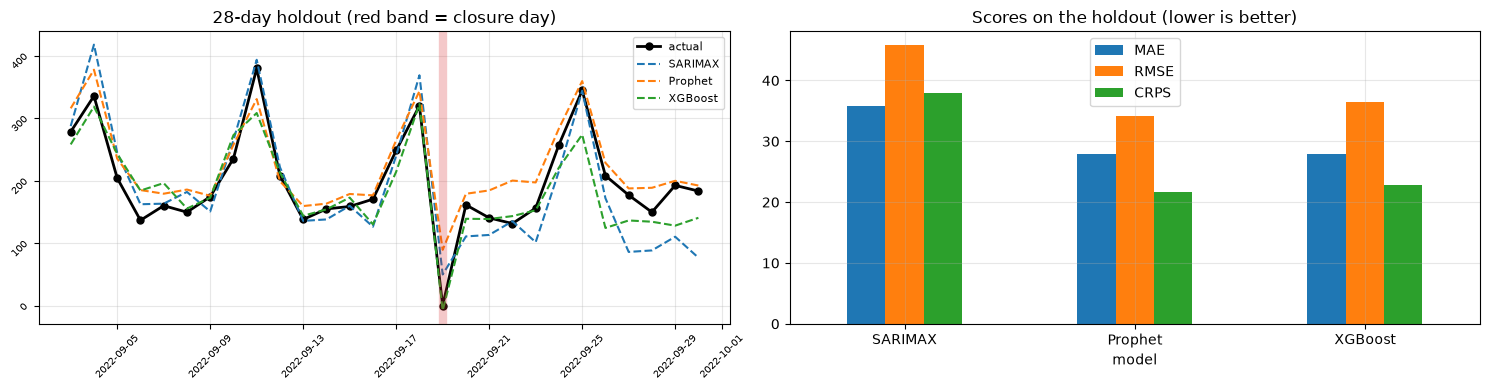

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(test.index, a, lw=2, color="black", marker="o", ms=5, label="actual")
axes[0].plot(test.index, mu_s, lw=1.5, ls="--", label="SARIMAX")
axes[0].plot(test.index, fc_p["yhat"], lw=1.5, ls="--", label="Prophet")
axes[0].plot(test.index, pred_x, lw=1.5, ls="--", label="XGBoost")
for d_ in test.index[a == 0]:
    axes[0].axvline(d_, color="tab:red", alpha=0.25, lw=6)
axes[0].tick_params(labelrotation=45, labelsize=7)
axes[0].legend(fontsize=8); axes[0].set_title("28-day holdout (red band = closure day)")

dfm = pd.DataFrame(rows).set_index("model")[["MAE", "RMSE", "CRPS"]]
dfm.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Scores on the holdout (lower is better)")
plt.tight_layout(); plt.show()

**Prophet and XGBoost are effectively tied on MAE** — 27.86 vs 27.89, a 0.1% difference over 28 points, which is noise. The metrics disagree about the rest, and that disagreement is informative:

| | Prophet | XGBoost | SARIMAX |
|---|---|---|---|
| MAE | **27.86** | 27.89 | 35.74 |
| RMSE | **34.15** | 36.51 | 45.79 |
| MAPE excl. 0 % | 13.99 | **13.86** | 18.51 |
| sMAPE % | **19.33** | 21.34 | 27.76 |
| CRPS | **21.56** | 22.83 | 38.01 |

- **Equal MAE but different RMSE** (34.15 vs 36.51) means XGBoost makes a few larger misses that Prophet avoids, while being slightly better on the typical day — which is also why XGBoost edges the percentage metric and loses the squared one. Which model you prefer depends on whether occasional large errors are costlier than routine small ones.
- **MAPE is `inf` for all three.** One closure day sets $y_t = 0$. The metric is unusable on this series regardless of which model produced the forecast — a property of the data, not the models.
- **SARIMAX's CRPS gap far exceeds its MAE gap**: 28% worse on MAE, but 76% worse on CRPS. Its Gaussian intervals are too wide, as diagnosed in [arima_family.ipynb](arima_family.ipynb). CRPS charges for that miscalibration; MAE cannot see it at all.

Note the CRPS figures for Prophet come from 1000 posterior draws, so they move by roughly ±0.2 between runs; the ordering is stable.

One window is not a ranking, so re-score over a rolling origin.

01:53:12 - cmdstanpy - INFO - Chain [1] start processing
01:53:12 - cmdstanpy - INFO - Chain [1] done processing
01:53:13 - cmdstanpy - INFO - Chain [1] start processing
01:53:13 - cmdstanpy - INFO - Chain [1] done processing
01:53:14 - cmdstanpy - INFO - Chain [1] start processing
01:53:14 - cmdstanpy - INFO - Chain [1] done processing
01:53:15 - cmdstanpy - INFO - Chain [1] start processing
01:53:15 - cmdstanpy - INFO - Chain [1] done processing


                        window MAEs  mean MAE
SARIMAX  [32.8, 180.4, 177.1, 35.7]    106.52
Prophet    [24.9, 99.3, 98.9, 27.9]     62.75
XGBoost   [33.5, 99.6, 120.7, 27.9]     70.43


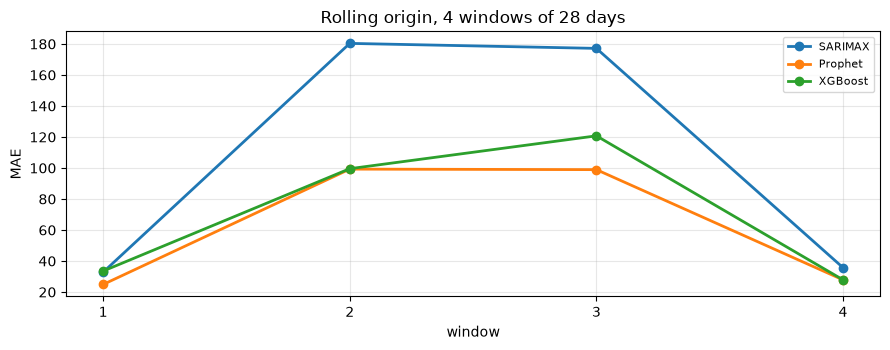

In [13]:
def forecast_all(cut, h=28):
    tr_, te_ = y[:cut], y[cut:cut + h]
    if len(te_) < h:
        return None
    out = {}

    m = SARIMAX(tr_, exog=Xc[:cut], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    out["SARIMAX"] = m.get_forecast(h, exog=Xc[cut:cut + h]).predicted_mean.values

    _, fc_, _ = fit_prophet(tr_, te_.index)
    out["Prophet"] = fc_["yhat"].values

    f_tr = F[F.index <= tr_.index[-1]]
    f_te = F[(F.index > tr_.index[-1]) & (F.index <= te_.index[-1])]
    reg = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=1)
    reg.fit(f_tr.drop(columns="y"), f_tr["y"])
    out["XGBoost"] = reg.predict(f_te.drop(columns="y"))
    return te_.values, out

n = len(y)
cuts = [n - 28 - 3*28, n - 28 - 2*28, n - 28 - 28, n - 28]

errs = {}
for c in cuts:                                   # ~1 minute
    got = forecast_all(c)
    if got is None:
        continue
    actual, preds = got
    for k, p in preds.items():
        errs.setdefault(k, []).append(np.abs(actual - p).mean())

cv = pd.DataFrame({"window MAEs": {k: [round(v, 1) for v in vs] for k, vs in errs.items()},
                   "mean MAE": {k: round(np.mean(vs), 2) for k, vs in errs.items()}})
print(cv.to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
for k, vs in errs.items():
    ax.plot(range(1, len(vs) + 1), vs, marker="o", lw=2, label=k)
ax.set_xticks(range(1, len(cuts) + 1)); ax.set_xlabel("window"); ax.set_ylabel("MAE")
ax.set_title("Rolling origin, 4 windows of 28 days")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**The ranking holds and the tie breaks:** Prophet 62.75 mean MAE, XGBoost 70.43, SARIMAX 106.52. Prophet and XGBoost were indistinguishable on the final window, but across four windows Prophet is ~11% better — a reminder that a single window could not have separated them.

Windows 2 and 3 are far worse for every model (99–180 MAE against 25–36). Those cover the July–August peak, where the level is roughly five times the winter baseline; MAE is scale-dependent, so the summer windows dominate the average. A scale-free metric such as MASE, or evaluating on the log scale, would weight the windows more evenly.

**Where each model fits this series:** Prophet's explicit trend + seasonality + holiday decomposition matches how the data is actually generated, and it needs no stationarity work. XGBoost matches it on typical days and would likely pull ahead with richer exogenous features, but it cannot extrapolate beyond the training range and it makes the larger tail errors here. SARIMAX is the weakest on points and by a wide margin the weakest on calibration.